## Data Loading

In [26]:
import numpy as np
import pandas as pd

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
traindf = pd.read_csv(r"datasets/train.csv")
testdf = pd.read_csv(r"datasets/test.csv")
storesdf = pd.read_csv(r"datasets/stores.csv")
featuresdf = pd.read_csv(r"datasets/features.csv")

### Understanding the data 

In [29]:
print(traindf.shape, testdf.shape,storesdf.shape,featuresdf.shape )

(421570, 5) (115064, 4) (45, 3) (8190, 12)


In [30]:
lst=[traindf,testdf,storesdf,featuresdf]
for every in lst:
    print(every.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3

# 1. DATA CLEANING |  PRE-PROCESSING
## 1.1 Handling missing values 
-  The missing values are mainly present in , Markdown1,Markdown2 ,Markdown3,Markdown4,Markdown5, cpi , Unemployment in Features data
-  As per dataset provide (kaggale : MarkDown1-5 - anonymized data related to promotional markdowns that Walmart is running. MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA.)

### for `MARKDOWNS` 
- MarkDown data is only available after Nov 2011, and is not available for all stores all the time.
- Iam filling with *0*
- Reason is A markdown represents spending on promotions. If it is missing, treating it as no promotion (0)   is a reasonable assumption and keeps the feature numeric.

In [31]:
markdown_col = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
featuresdf[markdown_col] = featuresdf[markdown_col].fillna(0)

In [32]:
# Now rechecking missing vals 
featuresdf.isna().sum()

Store             0
Date              0
Temperature       0
Fuel_Price        0
MarkDown1         0
MarkDown2         0
MarkDown3         0
MarkDown4         0
MarkDown5         0
CPI             585
Unemployment    585
IsHoliday         0
dtype: int64

In [33]:
# Ok now deal will 
# CPI - the consumer price index
# Unemployment - the unemployment rate

### 1.1.1 CPI & UNEMPLOYMENT 
- Since CPI and unemployment usually donot fluctuate dramatically week to week, the most practical approach is
- Iam using ffill() and fill() where nearby values are more meaningful than a global mean or median.

In [34]:
featuredf = featuresdf.sort_values(['Store', 'Date'])

In [35]:
CPI_UNEMP_cols=['CPI', 'Unemployment']
featuresdf[CPI_UNEMP_cols] = (
    featuresdf.groupby('Store')[CPI_UNEMP_cols]
            .ffill()
            .bfill()
)

In [36]:
# Now rechecking missing vals  again
featuresdf.isna().sum()

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64

In [37]:
lst=[traindf,testdf,storesdf,featuresdf]
for every in lst:
    print(every.isna().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64
Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


### No missing values were present
## 1.2 Checking for Duplicates 

In [38]:
datasets = {
    "train": traindf,
    "test": testdf,
    "stores": storesdf,
    "features": featuresdf
}
for name, df in datasets.items():
    print(f"{name} duplicates = {df.duplicated().sum()}")

train duplicates = 0
test duplicates = 0
stores duplicates = 0
features duplicates = 0


### No duplicates  were present

In [39]:
traindf['Date']

0         2010-02-05
1         2010-02-12
2         2010-02-19
3         2010-02-26
4         2010-03-05
             ...    
421565    2012-09-28
421566    2012-10-05
421567    2012-10-12
421568    2012-10-19
421569    2012-10-26
Name: Date, Length: 421570, dtype: object

### 1.3 Data Conversion
 #### 1.3.1 Converting  Date Column from  object to Date Format that helps in better Visualizations 

In [40]:
traindf['Date'] = pd.to_datetime(traindf['Date'])
testdf['Date'] = pd.to_datetime(testdf['Date'])
featuresdf['Date'] = pd.to_datetime(featuresdf['Date'])

In [41]:
traindf['Date']

0        2010-02-05
1        2010-02-12
2        2010-02-19
3        2010-02-26
4        2010-03-05
            ...    
421565   2012-09-28
421566   2012-10-05
421567   2012-10-12
421568   2012-10-19
421569   2012-10-26
Name: Date, Length: 421570, dtype: datetime64[ns]

### 1.4 MERGING DATA 

In [42]:
traindf = traindf.merge(
    featuresdf,
    on=['Store','Date','IsHoliday'],
    how='left'
)

In [43]:
testdf = testdf.merge(
    featuresdf,
    on=['Store','Date','IsHoliday'],
    how='left'
)

In [44]:

traindf = traindf.merge(
    storesdf,
    on='Store',
    how='left'
)

testdf = testdf.merge(
    storesdf,
    on='Store',
    how='left'
)

In [45]:
traindf.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315


In [46]:
testdf.head(2)

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315


####  1.3.2 Chaging `IsHoliday` BOOL -> INT  because it is easy to process with ML Algorithms and to maintain uniform in all features 


In [47]:
traindf['IsHoliday'] = traindf['IsHoliday'].astype(int)
testdf['IsHoliday'] = testdf['IsHoliday'].astype(int)

### 1.5 Date feature engineering
- ML models cannot directly understand dates, so we extract  year, month, and week.

In [48]:
traindf['Year'] = traindf['Date'].dt.year
traindf['Month'] = traindf['Date'].dt.month
traindf['Week'] = traindf['Date'].dt.isocalendar().week.astype(int)


In [49]:
testdf['Year'] = testdf['Date'].dt.year
testdf['Month'] = testdf['Date'].dt.month
testdf['Week'] = testdf['Date'].dt.isocalendar().week.astype(int)

In [50]:
traindf.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9


# 2. Exploratory Data Analysis (EDA):

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

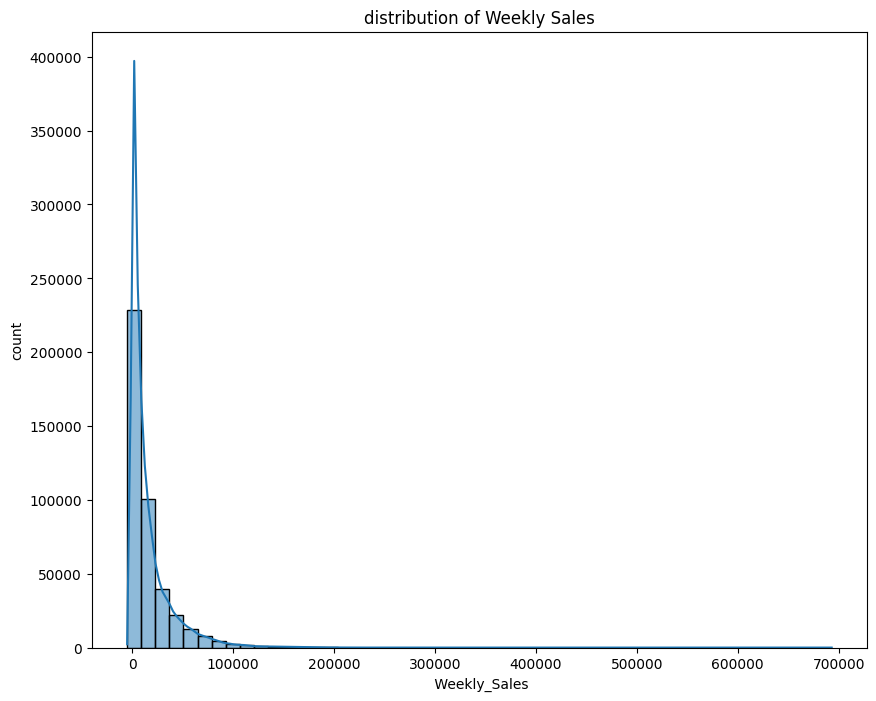

In [27]:
plt.figure(figsize=(10,8))
sns.histplot(traindf['Weekly_Sales'], bins=50, kde=True)
plt.title("distribution of Weekly Sales")
plt.xlabel(" Weekly_Sales")
plt.ylabel("count")
plt.show()

- Distribution of target varible

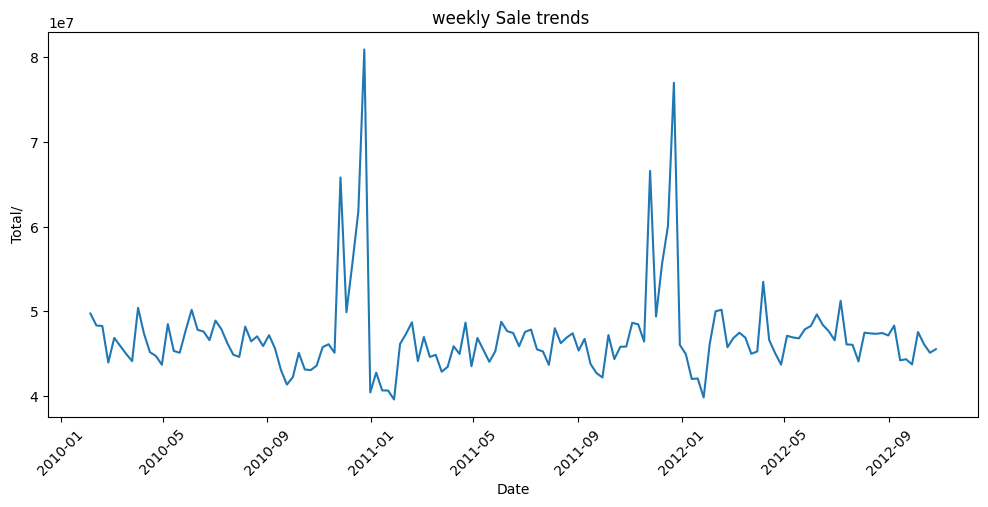

In [28]:
sales_time = traindf.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(sales_time['Date'], sales_time['Weekly_Sales'])
plt.title("weekly Sale trends ")
plt.xlabel("Date")
plt.ylabel("Total/")
plt.xticks(rotation=45)
plt.show()

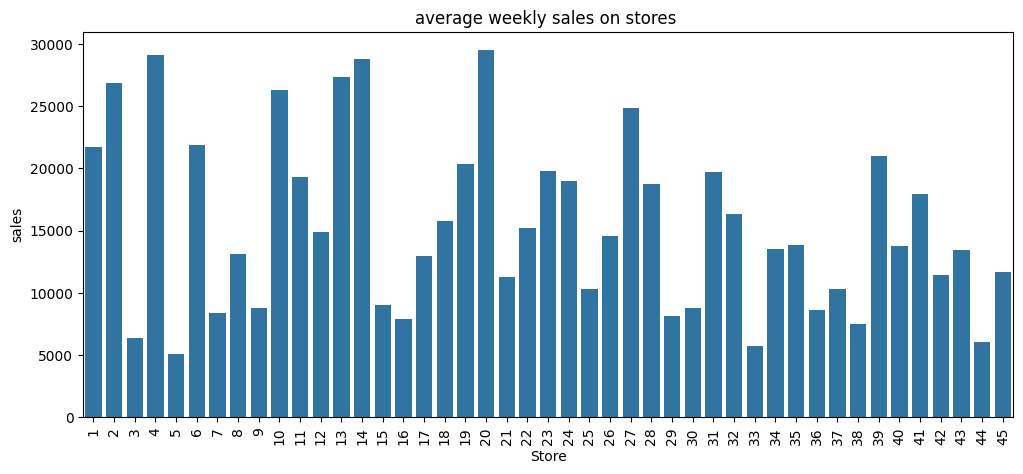

In [29]:
store_sales = traindf.groupby('Store')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=store_sales, x='Store', y='Weekly_Sales')
plt.title("average weekly sales on stores ")
plt.xlabel("Store")
plt.ylabel("sales")
plt.xticks(rotation=90)
plt.show()

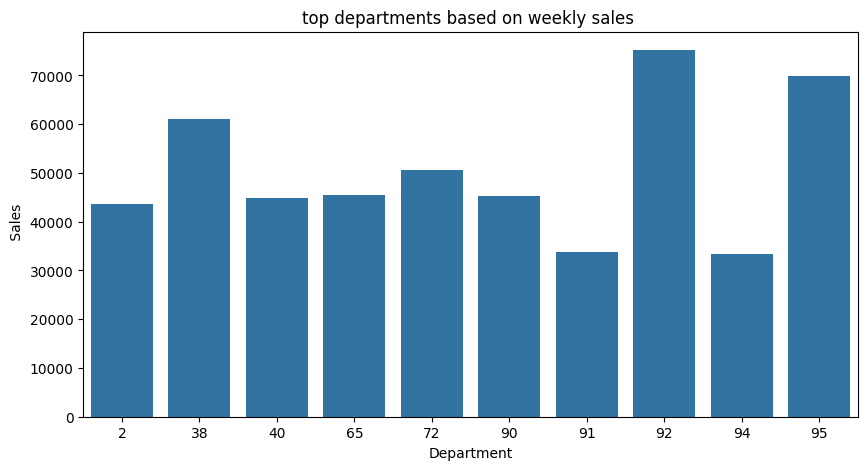

In [30]:
dept_sales = traindf.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=dept_sales, x='Dept', y='Weekly_Sales')
plt.title("top departments based on weekly sales ")
plt.xlabel("Department")
plt.ylabel(" Sales")
plt.show()

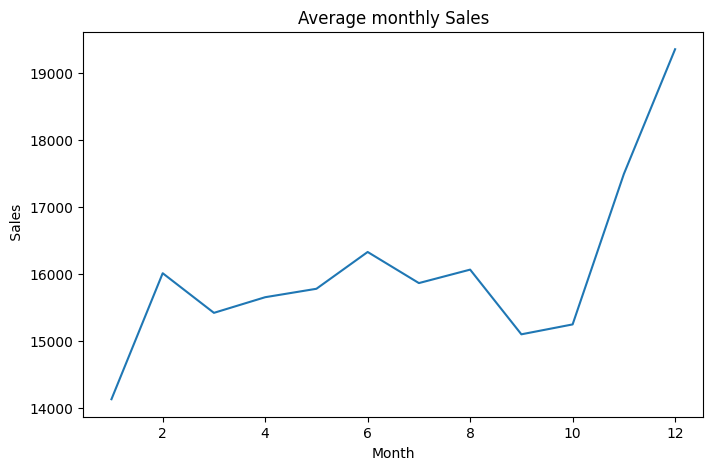

In [31]:
monthly_sales = traindf.groupby('Month')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_sales, x='Month', y='Weekly_Sales')
plt.title("Average monthly Sales")
plt.xlabel("Month")
plt.ylabel(" Sales")
plt.show()

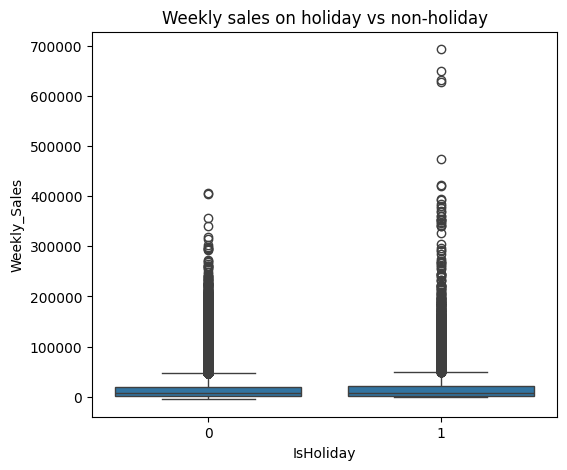

In [32]:
plt.figure(figsize=(6,5))
sns.boxplot(data=traindf, x='IsHoliday', y='Weekly_Sales')
plt.title("Weekly sales on holiday vs non-holiday")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly_Sales")
plt.show()

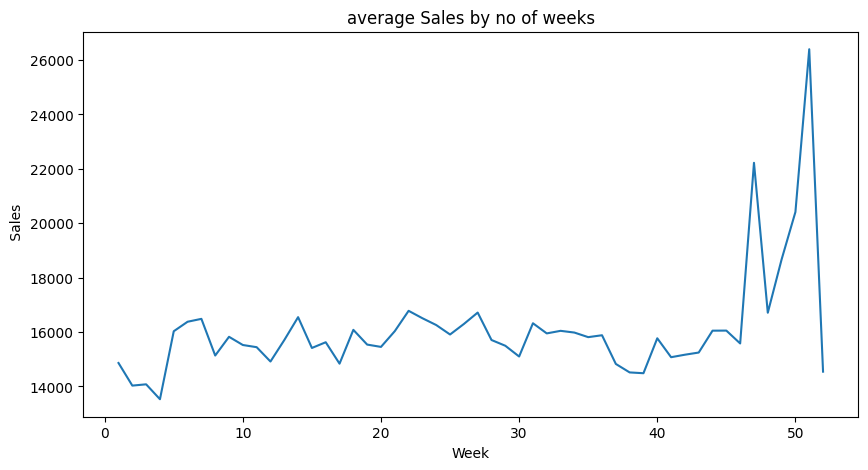

In [33]:
weekly_sales = traindf.groupby('Week')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=weekly_sales, x='Week', y='Weekly_Sales')
plt.title("average Sales by no of weeks")
plt.xlabel("Week")
plt.ylabel(" Sales")
plt.show()

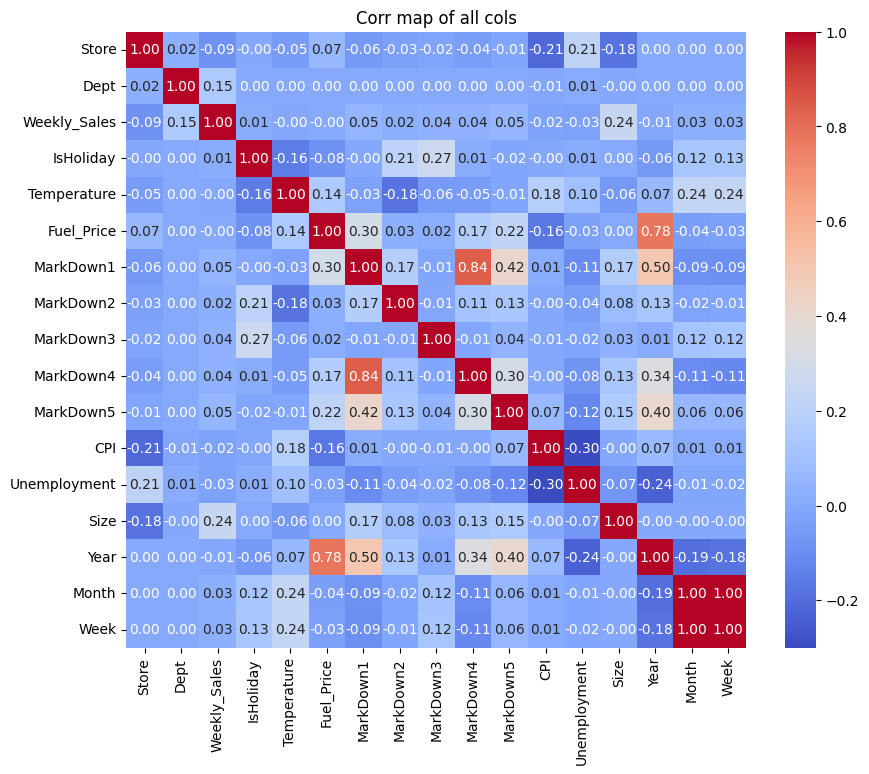

In [34]:
plt.figure(figsize=(10,8))
corr = traindf.select_dtypes(include=['number']).corr()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Corr map of all cols")
plt.show()

#### Most features have weak correlations with Weekly_Sales, indicating that sales are influenced by multiple factors rather than a single variable.

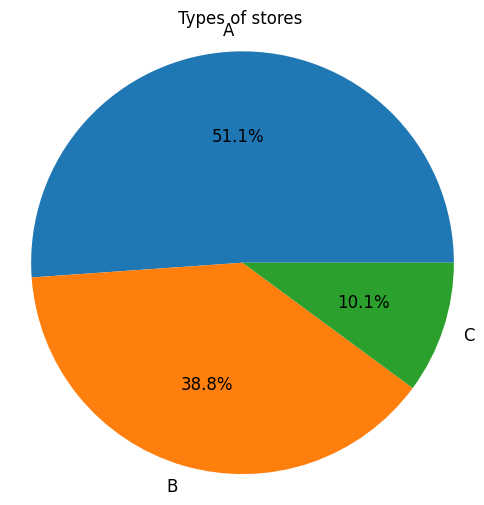

In [35]:

type_counts = traindf['Type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    textprops={'fontsize':12}
)

plt.title("Types of stores ")
plt.axis('equal')

plt.show()

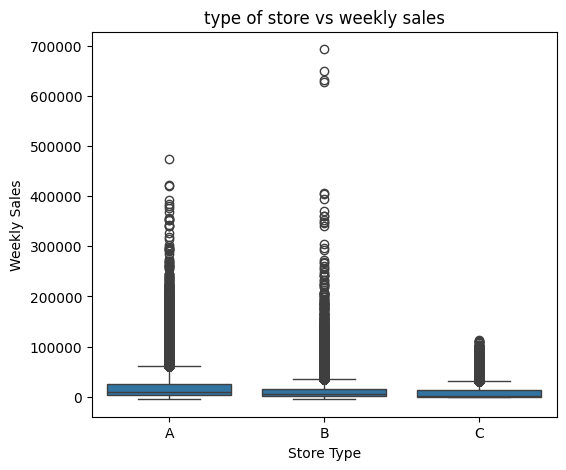

In [36]:
plt.figure(figsize=(6,5))
sns.boxplot(data=traindf, x='Type', y='Weekly_Sales')
plt.title("type of store vs weekly sales")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.show()

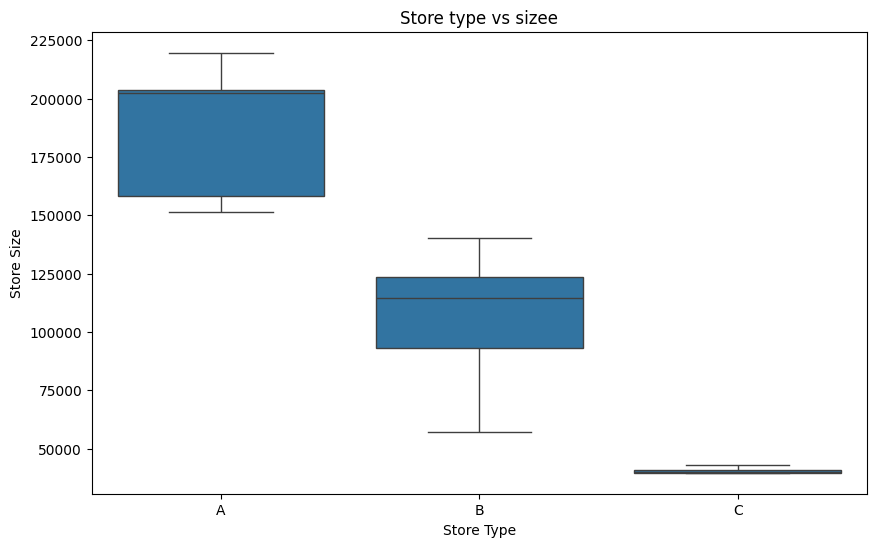

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=traindf,
    x='Type',
    y='Size',
    showfliers=False
)
plt.title("Store type vs sizee")
plt.xlabel("Store Type")
plt.ylabel("Store Size")
plt.show()

# 3. Feature Engineering

In [52]:
# combining  all markdown columns into a single promotional feature.
traindf['Total_MarkDown'] = (
    traindf['MarkDown1'] +
    traindf['MarkDown2'] +
    traindf['MarkDown3'] +
    traindf['MarkDown4'] +
    traindf['MarkDown5']
)

In [53]:
testdf['Total_MarkDown'] = (
    testdf['MarkDown1'] +
    testdf['MarkDown2'] +
    testdf['MarkDown3'] +
    testdf['MarkDown4'] +
    testdf['MarkDown5']
)

In [54]:
testdf['Total_MarkDown'] = (
    testdf['MarkDown1'] +
    testdf['MarkDown2'] +
    testdf['MarkDown3'] +
    testdf['MarkDown4'] +
    testdf['MarkDown5']
)

### we  cannot directly add lag/rolling features to the Kaggle testdf because:testdf does not have `Weekly_Sales`.

In [55]:
traindf.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Total_MarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010,2,5,0.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010,2,6,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010,2,7,0.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010,2,8,0.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010,3,9,0.0


In [56]:
# store Average sales 
store_avg = traindf.groupby('Store')['Weekly_Sales'].mean()
traindf['Store_Avg_Sales'] = traindf['Store'].map(store_avg)
testdf['Store_Avg_Sales'] = testdf['Store'].map(store_avg)

In [57]:
# dept avg sales 
dept_avg = traindf.groupby('Dept')['Weekly_Sales'].mean()
traindf['Dept_Avg_Sales'] = traindf['Dept'].map(dept_avg)
testdf['Dept_Avg_Sales'] = testdf['Dept'].map(dept_avg)

In [58]:
traindf['Temp_Fuel'] = traindf['Temperature'] * traindf['Fuel_Price']
testdf['Temp_Fuel'] = testdf['Temperature'] * testdf['Fuel_Price']

In [59]:
traindf['Economic_Index'] = traindf['CPI'] * traindf['Unemployment']
testdf['Economic_Index'] = testdf['CPI'] * testdf['Unemployment']

In [60]:
traindf.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Year', 'Month',
       'Week', 'Total_MarkDown', 'Store_Avg_Sales', 'Dept_Avg_Sales',
       'Temp_Fuel', 'Economic_Index'],
      dtype='object')

# 4. Segregating Features X & Target y

In [61]:
X_train = traindf.drop(['Weekly_Sales','Date'], axis=1)
y_train = traindf['Weekly_Sales']

In [62]:
X_test = testdf.drop('Date', axis=1)

# 5 .  Data Transformation

### 5.1 Categorical encoding

In [63]:
from sklearn.preprocessing import OneHotEncoder

In [64]:
ohe = OneHotEncoder(
    sparse_output=False,
).set_output(transform='pandas')
ohe

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_categ

In [65]:
train_type = ohe.fit_transform(X_train[['Type']])

In [66]:
test_type = ohe.transform(X_test[['Type']])

In [67]:
X_train = X_train.drop('Type', axis=1)
X_test = X_test.drop('Type', axis=1)

In [68]:
X_train = pd.concat([X_train, train_type], axis=1)

X_test = pd.concat([X_test, test_type], axis=1)

In [69]:
X_test.columns

Index(['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Total_MarkDown',
       'Store_Avg_Sales', 'Dept_Avg_Sales', 'Temp_Fuel', 'Economic_Index',
       'Type_A', 'Type_B', 'Type_C'],
      dtype='object')

In [70]:
X_train.columns

Index(['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Total_MarkDown',
       'Store_Avg_Sales', 'Dept_Avg_Sales', 'Temp_Fuel', 'Economic_Index',
       'Type_A', 'Type_B', 'Type_C'],
      dtype='object')

### 5.2 : Feature Scaling 


In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler().set_output(transform='pandas')
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [73]:
X_train_scaled = scaler.fit_transform(X_train)

In [74]:
X_test_scaled = scaler.transform(X_test)

In [75]:
X_train_scaled.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,Month,Week,Total_MarkDown,Store_Avg_Sales,Dept_Avg_Sales,Temp_Fuel,Economic_Index,Type_A,Type_B,Type_C
0,-1.658199,-1.418742,-0.275106,-0.963798,-1.720834,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,...,-1.371945,-1.471661,-0.453127,0.826302,0.194248,-1.326604,1.110594,0.977978,-0.795938,-0.335263
1,-1.658199,-1.418742,3.634961,-1.169783,-1.773177,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,...,-1.371945,-1.400999,-0.453127,0.826302,0.194248,-1.477004,1.114139,0.977978,-0.795938,-0.335263
2,-1.658199,-1.418742,-0.275106,-1.092810,-1.847330,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,...,-1.371945,-1.330337,-0.453127,0.826302,0.194248,-1.445223,1.115282,0.977978,-0.795938,-0.335263
3,-1.658199,-1.418742,-0.275106,-0.729625,-1.744825,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,...,-1.371945,-1.259675,-0.453127,0.826302,0.194248,-1.177605,1.116023,0.977978,-0.795938,-0.335263
4,-1.658199,-1.418742,-0.275106,-0.736672,-1.605243,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,...,-1.063609,-1.189013,-0.453127,0.826302,0.194248,-1.140446,1.116765,0.977978,-0.795938,-0.335263


In [76]:
X_test_scaled.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,Month,Week,Total_MarkDown,Store_Avg_Sales,Dept_Avg_Sales,Temp_Fuel,Economic_Index,Type_A,Type_B,Type_C
0,-1.658199,-1.418742,-0.275106,-0.258569,0.054466,0.690037,0.839355,-0.075471,0.656503,0.255405,...,1.403081,1.284158,0.790340,0.826302,0.194248,-0.223083,0.383651,0.977978,-0.795938,-0.335263
1,-1.658199,-1.418742,-0.275106,0.062335,-0.102563,1.459136,0.489901,-0.077377,0.915043,1.067440,...,1.403081,1.354820,1.284625,0.826302,0.194248,-0.003258,0.384016,0.977978,-0.795938,-0.335263
2,-1.658199,-1.418742,-0.275106,-0.388665,-0.237782,1.174118,-0.115620,-0.065892,0.012843,1.176416,...,1.403081,1.425482,0.756153,0.826302,0.194248,-0.437028,0.384640,0.977978,-0.795938,-0.335263
3,-1.658199,-1.418742,3.634961,-0.209241,-0.327202,-0.281953,-0.172249,13.464284,-0.224218,-0.323093,...,1.403081,1.496144,4.720197,0.826302,0.194248,-0.318107,0.385606,0.977978,-0.795938,-0.335263
4,-1.658199,-1.418742,-0.275106,-0.420105,-0.335925,-0.021487,-0.173069,0.609576,-0.239455,1.260466,...,1.403081,1.566806,0.456327,0.826302,0.194248,-0.496658,0.386573,0.977978,-0.795938,-0.335263


## 6. Model Building 

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [78]:
Linear_Regression = LinearRegression()

In [79]:
Random_Forest = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [80]:
XGBoost = XGBRegressor(
    n_estimators=30,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [81]:
split = int(len(X_train) * 0.8)

X_train_final = X_train.iloc[:split]
X_valid = X_train.iloc[split:]

y_train_final = y_train.iloc[:split]
y_valid = y_train.iloc[split:]

In [82]:
X_train_scaled_final = X_train_scaled.iloc[:split]
X_valid_scaled = X_train_scaled.iloc[split:]

In [83]:
Linear_Regression.fit(X_train_scaled_final, y_train_final)

lr_pred = Linear_Regression.predict(X_valid_scaled)

In [84]:
lr_pred

array([2141.87393972, 2718.27945413, 2917.16707993, ..., 1592.21083941,
       1332.22937135, 1197.529412  ])

In [85]:
Random_Forest.fit(X_train_final, y_train_final)

rf_pred = Random_Forest.predict(X_valid)

In [86]:
rf_pred

array([3011.04928111, 3011.04928111, 3011.04928111, ..., 1985.96816565,
       1985.96816565, 1994.56759898])

In [87]:
XGBoost.fit(X_train, y_train)
xgb_pred = XGBoost.predict(X_test)

In [88]:
xgb_pred

array([25609.25  , 25855.307 , 25609.25  , ...,  2944.2913,  2944.2913,
        2944.2913], dtype=float32)

In [89]:
def WMAE(y_true,y_pred,weights):

    return np.sum(weights*np.abs(y_true-y_pred))/np.sum(weights)

In [90]:
weights = np.where(
    X_valid['IsHoliday']==True,  5,  1
)

# 7 Hperparameter Tuning 

In [77]:
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import r2_score

In [78]:
def Objective(trial):

    model_name = trial.suggest_categorical(
        'Model', ['Linear Regression','Random Forest','XGBoost'])
    if model_name == 'Linear Regression':
        model = LinearRegression(
            fit_intercept=trial.suggest_categorical('fit_intercept',[True,False]),
            positive=trial.suggest_categorical('positive',[True,False]),
            n_jobs=-1)
        model.fit(X_train_scaled_final,y_train_final)
        pred = model.predict(X_valid_scaled)
    elif model_name == 'Random Forest':
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators',100,300),
            max_depth=trial.suggest_int('max_depth',10,30),
            min_samples_split=trial.suggest_int('min_samples_split',2,8),
            min_samples_leaf=trial.suggest_int('min_samples_leaf',1,4),
            max_features=trial.suggest_categorical(
                'max_features',
                ['sqrt','log2']
            ),
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_final,y_train_final)
        pred = model.predict(X_valid)

    else:
        model = XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators',100,400),
            max_depth=trial.suggest_int('max_depth',4,8),
            learning_rate=trial.suggest_float('learning_rate',0.03,0.15),
            subsample=trial.suggest_float('subsample',0.8,1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree',0.8,1.0),
            min_child_weight=trial.suggest_int('min_child_weight',1,7),
            gamma=trial.suggest_float('gamma',0,3),
            reg_alpha=trial.suggest_float('reg_alpha',0,1),
            reg_lambda=trial.suggest_float('reg_lambda',1,5),
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_final,y_train_final)
        pred = model.predict(X_valid)

    score = WMAE( y_valid, pred, weights )
    return score

In [79]:
study = optuna.create_study( direction='minimize', study_name='Walmart Forecasting',
                            sampler=TPESampler(seed=42)
)

[I 2026-07-10 12:09:53,694] A new study created in memory with name: Walmart Forecasting


In [80]:
study.optimize(Objective, n_trials=50)

[I 2026-07-10 12:10:19,686] Trial 0 finished with value: 5319.938899604407 and parameters: {'Model': 'Random Forest', 'n_estimators': 220, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 5319.938899604407.
[I 2026-07-10 12:11:23,408] Trial 1 finished with value: 5139.013105871237 and parameters: {'Model': 'XGBoost', 'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.051818996064852074, 'subsample': 0.8366809019706868, 'colsample_bytree': 0.8608484485919076, 'min_child_weight': 4, 'gamma': 1.2958350559263474, 'reg_alpha': 0.2912291401980419, 'reg_lambda': 3.447411578889518}. Best is trial 1 with value: 5139.013105871237.
[I 2026-07-10 12:12:10,840] Trial 2 finished with value: 5494.243157723715 and parameters: {'Model': 'XGBoost', 'n_estimators': 237, 'max_depth': 7, 'learning_rate': 0.05396085385900316, 'subsample': 0.9028468876827224, 'colsample_bytree': 0.9184829137724085, 'min_child_weight': 1, 'gamma': 1.8226

In [81]:
print("Best WMAE Score :",study.best_value)

print("Best Parameters :", study.best_params)

Best WMAE Score : 4602.704865703773
Best Parameters : {'Model': 'Random Forest', 'n_estimators': 220, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}


In [82]:
import joblib

joblib.dump(
    study,
    "optuna_study.pkl"
)

print("Study saved successfully.")

Study saved successfully.


In [2]:
import joblib
study = joblib.load(
    "optuna_study.pkl"
)

In [12]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_Model,params_colsample_bytree,params_fit_intercept,params_gamma,params_learning_rate,...,params_max_features,params_min_child_weight,params_min_samples_leaf,params_min_samples_split,params_n_estimators,params_positive,params_reg_alpha,params_reg_lambda,params_subsample,state
0,0,5319.938900,2026-07-10 12:09:53.708397,2026-07-10 12:10:19.686265,0 days 00:00:25.977868,Random Forest,NaN,NaN,NaN,NaN,...,sqrt,NaN,1.0,3.0,220.0,NaN,NaN,NaN,NaN,COMPLETE
1,1,5139.013106,2026-07-10 12:10:19.688276,2026-07-10 12:11:23.408231,0 days 00:01:03.719955,XGBoost,0.860848,NaN,1.295835,0.051819,...,NaN,4.0,NaN,NaN,350.0,NaN,0.291229,3.447412,0.836681,COMPLETE
2,2,5494.243158,2026-07-10 12:11:23.411230,2026-07-10 12:12:10.840981,0 days 00:00:47.429751,XGBoost,0.918483,NaN,1.822635,0.053961,...,NaN,1.0,NaN,NaN,237.0,NaN,0.170524,1.260206,0.902847,COMPLETE
3,3,5472.346450,2026-07-10 12:12:10.842988,2026-07-10 12:12:23.384137,0 days 00:00:12.541149,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,2.0,6.0,161.0,NaN,NaN,NaN,NaN,COMPLETE
4,4,5045.266734,2026-07-10 12:12:23.384137,2026-07-10 12:12:49.703534,0 days 00:00:26.319397,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,3.0,5.0,233.0,NaN,NaN,NaN,NaN,COMPLETE
5,5,4602.704866,2026-07-10 12:12:49.719618,2026-07-10 12:13:43.151787,0 days 00:00:53.432169,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,1.0,2.0,220.0,NaN,NaN,NaN,NaN,COMPLETE
6,6,5231.649989,2026-07-10 12:13:43.167867,2026-07-10 12:14:14.305344,0 days 00:00:31.137477,XGBoost,0.960439,NaN,2.960661,0.095124,...,NaN,1.0,NaN,NaN,207.0,NaN,0.772245,1.794863,0.828185,COMPLETE
7,7,4733.707520,2026-07-10 12:14:14.309098,2026-07-10 12:14:51.136597,0 days 00:00:36.827499,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,2.0,2.0,246.0,NaN,NaN,NaN,NaN,COMPLETE
8,8,32358.862875,2026-07-10 12:14:51.153486,2026-07-10 12:14:54.560263,0 days 00:00:03.406777,Linear Regression,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,COMPLETE
9,9,37036.336853,2026-07-10 12:14:54.562276,2026-07-10 12:14:54.891631,0 days 00:00:00.329355,Linear Regression,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,COMPLETE


In [122]:

trials_df = study.trials_dataframe()
trials_df.head()

,number,value,datetime_start,datetime_complete,duration,params_Model,params_colsample_bytree,params_fit_intercept,params_gamma,params_learning_rate,...,params_max_features,params_min_child_weight,params_min_samples_leaf,params_min_samples_split,params_n_estimators,params_positive,params_reg_alpha,params_reg_lambda,params_subsample,state
0,0,5319.938900,2026-07-10 12:09:53.708397,2026-07-10 12:10:19.686265,0 days 00:00:25.977868,Random Forest,NaN,NaN,NaN,NaN,...,sqrt,NaN,1.0,3.0,220.0,NaN,NaN,NaN,NaN,COMPLETE
1,1,5139.013106,2026-07-10 12:10:19.688276,2026-07-10 12:11:23.408231,0 days 00:01:03.719955,XGBoost,0.860848,NaN,1.295835,0.051819,...,NaN,4.0,NaN,NaN,350.0,NaN,0.291229,3.447412,0.836681,COMPLETE
2,2,5494.243158,2026-07-10 12:11:23.411230,2026-07-10 12:12:10.840981,0 days 00:00:47.429751,XGBoost,0.918483,NaN,1.822635,0.053961,...,NaN,1.0,NaN,NaN,237.0,NaN,0.170524,1.260206,0.902847,COMPLETE
3,3,5472.346450,2026-07-10 12:12:10.842988,2026-07-10 12:12:23.384137,0 days 00:00:12.541149,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,2.0,6.0,161.0,NaN,NaN,NaN,NaN,COMPLETE
4,4,5045.266734,2026-07-10 12:12:23.384137,2026-07-10 12:12:49.703534,0 days 00:00:26.319397,Random Forest,NaN,NaN,NaN,NaN,...,log2,NaN,3.0,5.0,233.0,NaN,NaN,NaN,NaN,COMPLETE


In [123]:
trials_df.to_csv("optuna_trials.csv", index=False)

# 8. Model Evaluation

In [102]:
Best_Model = RandomForestRegressor(
    n_estimators=220,
    max_depth=29,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

In [103]:
Best_Model.fit(X_train_final,y_train_final)
Best_Model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",220
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",29
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [104]:
best_pred = Best_Model.predict(  X_valid)
best_pred

array([3137.66213824, 2470.27596201, 3215.43084539, ..., 2222.98362603,
       2161.58865634, 2340.29589876])

### 8.1 Metrics 

In [87]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error, r2_score

In [88]:
mae = mean_absolute_error(y_valid,best_pred)
rmse = np.sqrt(mean_squared_error(y_valid,best_pred))
mape = mean_absolute_percentage_error(y_valid,best_pred)
r2 = r2_score(y_valid,best_pred)

In [89]:
print("Model is  Tuned Random Forest")
print("MAE :",mae)
print("RMSE :",rmse)
print("MAPE :",mape)
print("R2 Score :",r2)

Model is  Tuned Random Forest
MAE : 4452.036694161161
RMSE : 8053.283768652559
MAPE : 990753699238956.1
R2 Score : 0.8209293699285288


### 8.2 residual analysis 

In [90]:
residuals = y_valid-best_pred
residuals

337256    2622.337862
337257    2630.724038
337258    1094.569155
337259    1235.266807
337260    2336.387500
             ...     
421565   -1733.168364
421566   -1759.762500
421567   -1161.963626
421568   -1401.578656
421569   -1263.495899
Name: Weekly_Sales, Length: 84314, dtype: float64

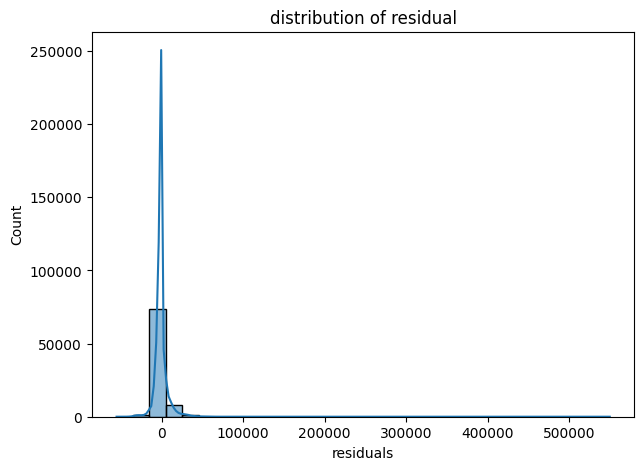

In [91]:
plt.figure(figsize=(7,5))
sns.histplot( residuals, bins=30,kde=True)
plt.title("distribution of residual")
plt.xlabel("residuals")
plt.show()

- Most residuals are concentrated around zero, indicating the model predicts the majority of sales reasonably well.

In [92]:
from scipy import stats

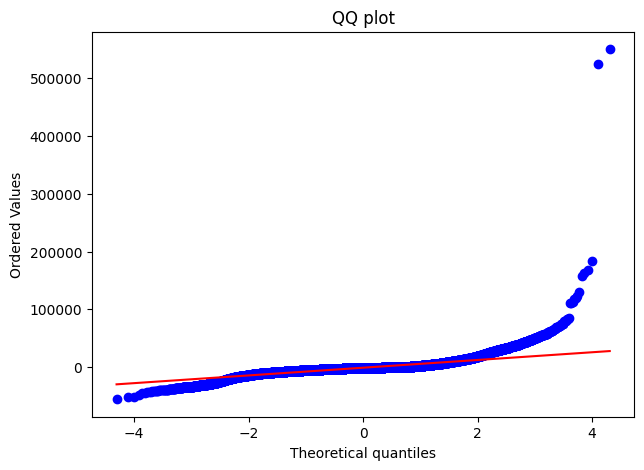

In [93]:
plt.figure(figsize=(7,5))
stats.probplot(residuals,dist='norm', plot=plt)
plt.title("QQ plot")
plt.show()

- Here residuals follow the normal distribution

# 9. Robustness Testing

### 9.1 Holiday vs Non-Holiday

In [94]:
holiday_results = pd.DataFrame({'Actual':y_valid,'Predicted':best_pred,'IsHoliday':X_valid['IsHoliday']})
holiday_results.head()

,Actual,Predicted,IsHoliday
337256,5760.0,3137.662138,1
337257,5101.0,2470.275962,0
337258,4310.0,3215.430845,0
337259,4285.0,3049.733193,0
337260,6088.0,3751.612500,0


In [95]:
holiday_mae = mean_absolute_error( holiday_results[holiday_results['IsHoliday']==True]['Actual'],holiday_results[holiday_results['IsHoliday']==True]['Predicted'])
nonholiday_mae = mean_absolute_error(  holiday_results[holiday_results['IsHoliday']==False]['Actual'],  holiday_results[holiday_results['IsHoliday']==False]['Predicted'])
print("MAE of holiday  :",holiday_mae)
print("MAE of non-holiday  :",nonholiday_mae)

MAE of holiday  : 5139.076940329841
MAE of non-holiday  : 4400.144748482788


### 9.2 Store Type Performance

In [96]:
store_results = pd.DataFrame({'Actual':y_valid,
    'Predicted':best_pred,
    'Type_A':X_valid['Type_A'],
    'Type_B':X_valid['Type_B'],
    'Type_C':X_valid['Type_C']})
store_results['Store_Type']='C'
store_results.loc[
    store_results['Type_A']==1,
    'Store_Type']='A'
store_results.loc[
    store_results['Type_B']==1,
    'Store_Type']='B'

store_results.head()

,Actual,Predicted,Type_A,Type_B,Type_C,Store_Type
337256,5760.0,3137.662138,0.0,1.0,0.0,B
337257,5101.0,2470.275962,0.0,1.0,0.0,B
337258,4310.0,3215.430845,0.0,1.0,0.0,B
337259,4285.0,3049.733193,0.0,1.0,0.0,B
337260,6088.0,3751.612500,0.0,1.0,0.0,B


In [97]:
for i in ['A','B','C']:
     mae=mean_absolute_error(
        store_results[store_results['Store_Type']==i]['Actual'],store_results[store_results['Store_Type']==i]['Predicted'] )
     print(i," MAE...",mae)

A  MAE... 4220.4230393017815
B  MAE... 4011.868375481035
C  MAE... 4845.9766122002575


# 10. Model Explainability 

## 10.1 LIME -Local Interpretability

In [98]:
%pip install lime

Note: you may need to restart the kernel to use updated packages.


In [99]:
from lime.lime_tabular import LimeTabularExplainer

In [100]:


explainer = LimeTabularExplainer(
    training_data=X_train_final.values,
    feature_names=X_train_final.columns.tolist(),
    mode='regression',
    random_state=42
)

In [101]:
exp = explainer.explain_instance(
    data_row=X_valid.iloc[0].values,
    predict_fn=Best_Model.predict,
    num_features=10
)

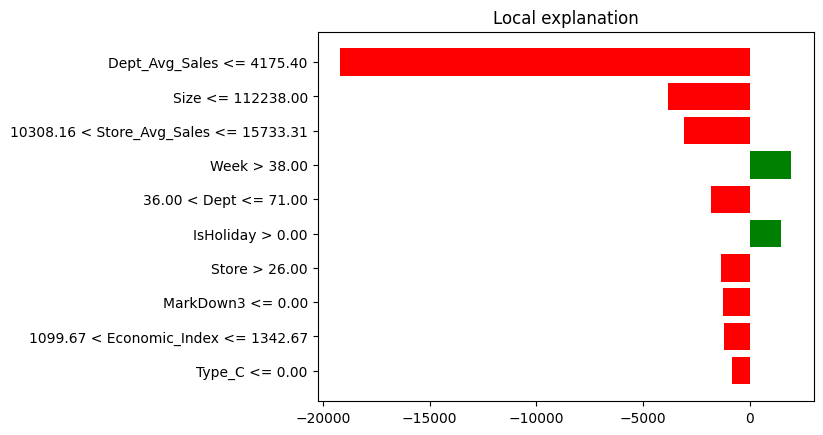

In [102]:
exp.as_pyplot_figure()
plt.show()

In [103]:
print(exp.as_list())

[('Dept_Avg_Sales <= 4175.40', -19199.374768065376), ('Size <= 112238.00', -3843.1669857412467), ('10308.16 < Store_Avg_Sales <= 15733.31', -3100.2402626348453), ('Week > 38.00', 1941.1790828238445), ('36.00 < Dept <= 71.00', -1814.0800432372541), ('IsHoliday > 0.00', 1489.3700094269748), ('Store > 26.00', -1361.499696284076), ('MarkDown3 <= 0.00', -1244.354692101896), ('1099.67 < Economic_Index <= 1342.67', -1194.906875403878), ('Type_C <= 0.00', -825.7227350187375)]


- The LIME prediction interpretation shows the features contributing the most to the selected sales prediction.
- A department’s average sales were the feature contributing most to the selected prediction negatively.
- Some of the key features that affected the selected sales prediction include store size and historical store average sales.
- Other features affecting the prediction included holiday and week number, but their effects were relatively minor compared to those of sales- related features.

### SHAP - Global Interpretability

In [105]:
!pip install shap

In [105]:
import shap

In [106]:
import shap
print(shap.__version__)

0.52.0


In [109]:
X_shap = X_test.sample(50, random_state=42) # Giving entire data takes infinite time so giving igt for 100 samplea 

In [110]:
explainer = shap.TreeExplainer(Best_Model)
explainer

In [111]:
shap_values = explainer.shap_values(X_shap)
shap_values

array([[ 1.28041404e+02, -7.95899020e+02,  1.49204090e+00, ...,
        -4.04241136e+02, -1.54553715e+02,  3.68997974e+01],
       [-1.11110129e+03, -7.28433430e+02, -5.21015400e+00, ...,
        -6.00714691e+02, -3.08065202e+02, -7.44105142e+02],
       [ 2.18437799e+02, -9.38178533e+02, -4.37939952e+00, ...,
        -2.69633203e+02, -1.08159216e+02,  1.49652843e+01],
       ...,
       [-1.47902967e+01, -9.82886562e+02, -4.58921150e+00, ...,
        -4.21665971e+02, -2.51234663e+02,  1.66460714e+01],
       [ 1.07680848e+02, -1.66708203e+03,  5.69193533e+01, ...,
        -1.56994312e+01,  1.17519224e+02,  1.17561129e+01],
       [ 1.31486900e+03,  2.23208528e+03, -7.54964505e+00, ...,
         6.56162035e+02,  3.36078439e+02,  4.88382233e+01]])

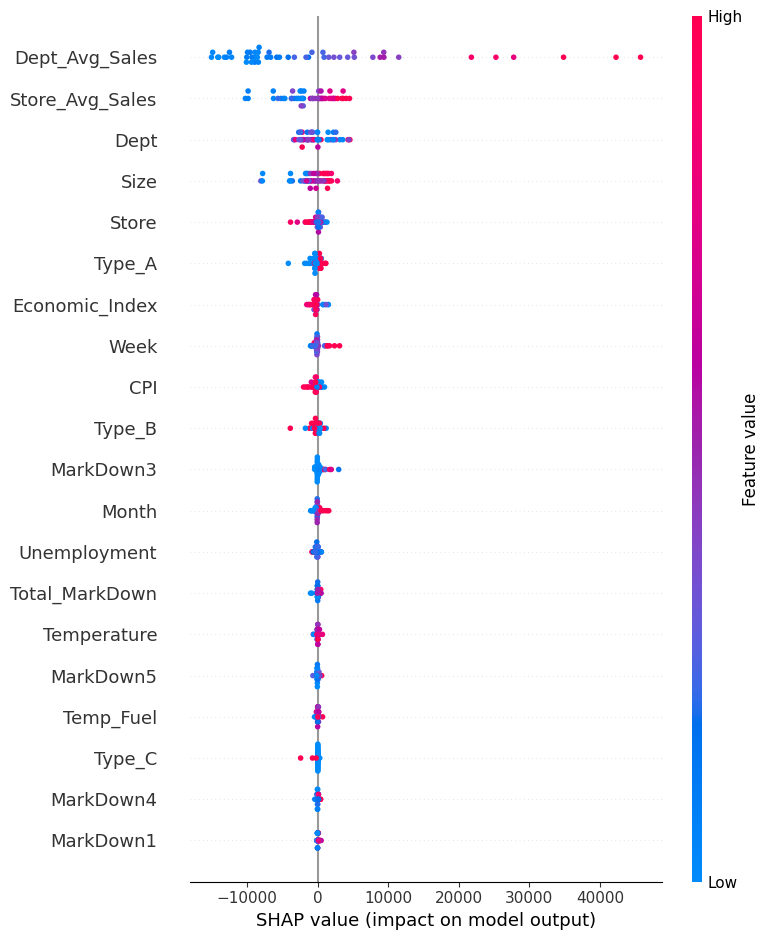

In [112]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()


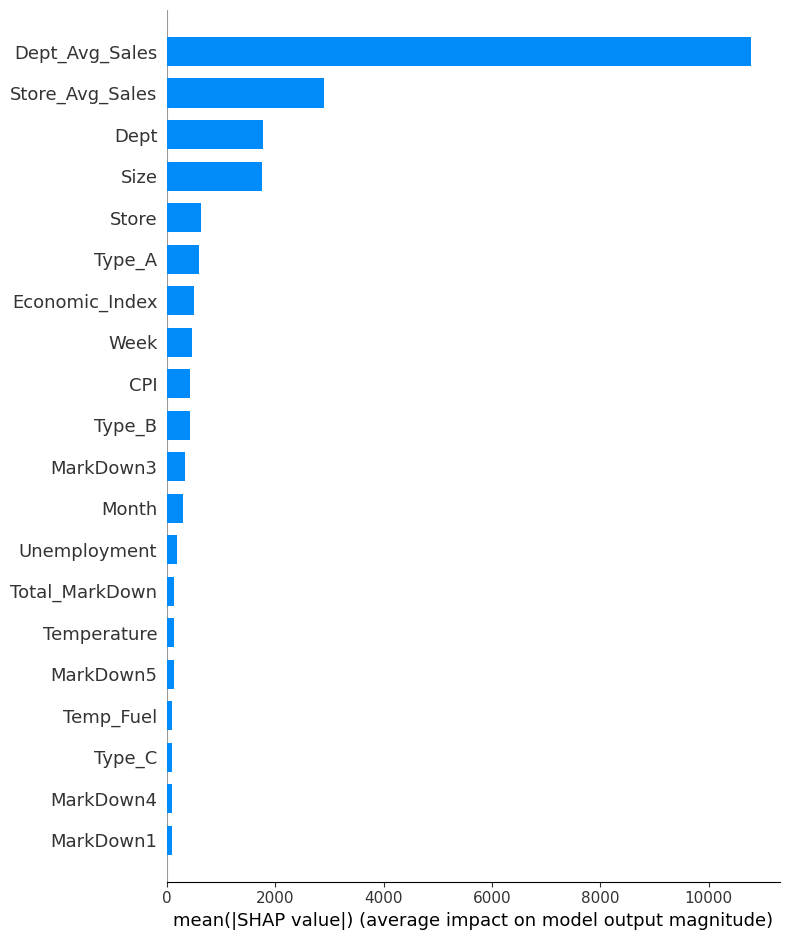

In [113]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

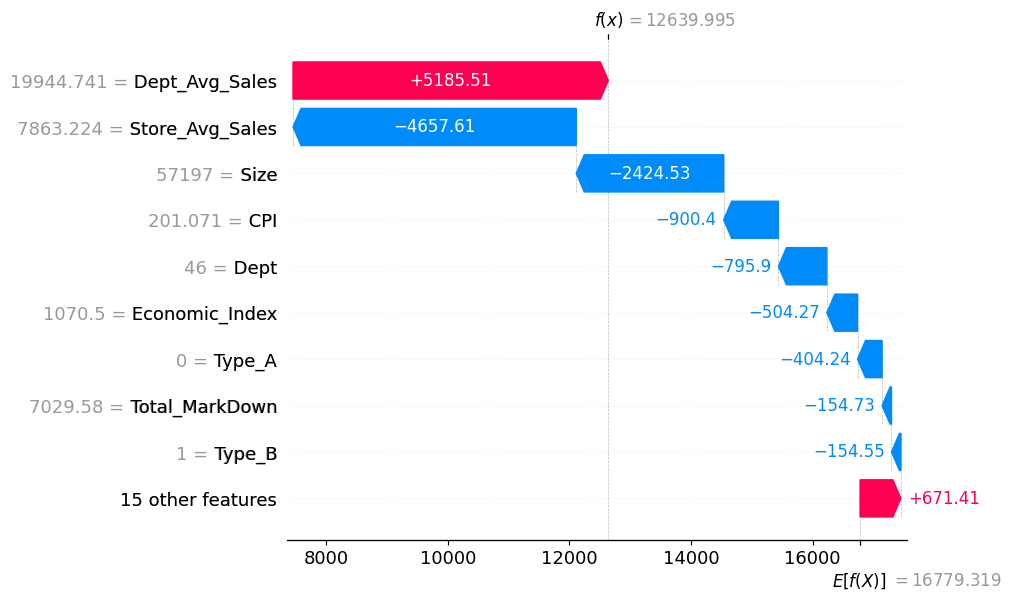

In [115]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_shap.iloc[sample_index],
        feature_names=X_shap.columns
    )
)

- High values for Dept_Avg_Sales lead to positive SHAP values, which in turn enhance the expected retail demand.
- Low values for historical department sales cause decreased demand forecasts from the model.
- The clustering of SHAP values around zero for most of the variables signifies that not all but just a few variables matter for the model.
- The dispersion of SHAP values for Dept_Avg_Sales reveals the important role played by the variable for the model.
- The SHAP analysis validates the fact that the XGBoost model mainly uses past sales data along with the help of other predictor variables.